In [2]:
import numpy as np
import scipy.sparse as sp
import time
import matplotlib.pyplot as plt

from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.model_selection import KFold, StratifiedKFold, train_test_split
from sklearn.svm import SVC
import os

In [3]:
def load_path(filename):
    """
    Returns a valid path for the dataset.
    Works on Google Colab, Windows, Linux, macOS, VS Code, PyCharm.
    """

    # 1) Local folder (Windows, Linux, macOS, VS Code, PyCharm)
    if os.path.exists(filename):
        return filename

    # 2) Google Colab default folder
    colab_path = os.path.join("/content", filename)
    if os.path.exists(colab_path):
        return colab_path

    # 3) Google Colab sample_data folder
    colab_sample = os.path.join("/content/sample_data", filename)
    if os.path.exists(colab_sample):
        return colab_sample

    raise FileNotFoundError(
        f"Dataset '{filename}' not found.\n"
        f"Place it in the same folder as the notebook/script."
    )

In [4]:
def load_dataset(name):
    if name == "toy":
        path = load_path("toydata_tiny.csv")
        data = np.genfromtxt(path, delimiter=",", skip_header=1)
        X = data[:, :-1]
        y = np.where(data[:, -1] == 0, -1, 1)
        return X, y

    elif name == "toy_large":
        path = load_path("toydata_large.csv")
        data = np.genfromtxt(path, delimiter=",", skip_header=1)
        X = data[:, :-1]
        y = np.where(data[:, -1] == 0, -1, 1)
        return X, y

    elif name == "imdb":
        path = load_path("imdb.npz")
        data = np.load(path, allow_pickle=True)

        Xt, Xs = data["train"], data["test"]
        X_train = Xt.item() if Xt.ndim == 0 else Xt
        X_test  = Xs.item() if Xs.ndim == 0 else Xs

        y_train = np.where(data["train_labels"] == 0, -1, 1)
        y_test  = np.where(data["test_labels"] == 0, -1, 1)

        return X_train, y_train, X_test, y_test

    elif name == "higgs":
        path = load_path("higgs.npz")
        data = np.load(path, allow_pickle=True)

        Xt, Xs = data["train"], data["test"]
        X_train = Xt.item() if Xt.ndim == 0 else Xt
        X_test  = Xs.item() if Xs.ndim == 0 else Xs

        y_train = np.where(data["train_labels"] == 0, -1, 1)
        y_test  = np.where(data["test_labels"] == 0, -1, 1)

        return X_train, y_train, X_test, y_test

    else:
        raise ValueError("Unknown dataset name")


Task 1: Linear SVM with SGD

In [5]:
def get_mini_batches(X, y, batch_size, shuffle=True):
     # number of samples
    n = X.shape[0]
    # create index list
    idx = np.arange(n)

    # shuffle indices if needed
    if shuffle:
        np.random.shuffle(idx)
    # go through data in steps of batch_size
    for i in range(0, n, batch_size):
        batch_idx = idx[i:i+batch_size]
         # get X batch (handle sparse matrices safely)
        Xb = X[batch_idx] if not sp.issparse(X) else X[batch_idx, :]
        yb = y[batch_idx].ravel()
         # return the batch
        yield Xb, yb

In [6]:
class LinearSVM:
    def __init__(self, dim, lam=1e-4):
        self.w = np.zeros(dim)
        self.lam = lam 

    def compute_score(self, X):
        return X.dot(self.w) if sp.issparse(X) else X @ self.w

    def predict(self, X):
        return np.where(self.compute_score(X) >= 0, 1, -1)

    def batch_gradient(self, Xb, yb):
        scores = self.compute_score(Xb)
        margins = 1 - yb * scores
        active = margins > 0

        if not np.any(active):
            return self.lam * self.w

        y_act = yb[active]

        if sp.issparse(Xb):
            Xa = Xb[active]
            g = Xa.T.dot(y_act)

        # ensure dense 1D vector
            if sp.issparse(g):
                g = g.toarray().ravel()
            else:
                g = np.asarray(g).ravel()

            g = -g / len(y_act)

        else:
            Xa = Xb[active]
            g = -(Xa.T @ y_act) / len(y_act)

        return self.lam * self.w + g

In [7]:
class SGD:
    def __init__(self, lr=1e-2):
        self.lr = lr
    # basic SGD update: w ← w - lr * gradient
    def update_weights(self, w, grad):
        return w - self.lr * grad


class MomentumSGD:
    def __init__(self, dim, lr=1e-2, momentum=0.9):
        self.lr = lr
        self.momentum = momentum    # momentum factor
        self.v = np.zeros(dim)       # velocity term

    def update_weights(self, w, grad):
        # update velocity: v ← m*v - lr*grad
        self.v = self.momentum * self.v - self.lr * grad
        return w + self.v


class Adagrad:
    def __init__(self, dim, lr=1e-1, eps=1e-8):
        self.lr = lr
        self.eps = eps
        self.G = np.zeros(dim)

    def update_weights(self, w, grad):
        self.G += grad * grad
        adjusted_lr = self.lr / (np.sqrt(self.G) + self.eps)
        return w - adjusted_lr * grad

SGD:  
Updates the weights using the basic gradient step:

𝑤←𝑤−𝜂𝑔
It is simple and fast but can be noisy.

Momentum:  
Adds a “speed” term that smooths the updates:

𝑣←𝛽𝑣−𝜂𝑔, 𝑤←𝑤+𝑣
This helps the model move more steadily.

Adagrad:  
Changes the learning rate for each weight based on past gradients:

𝐺←𝐺+𝑔^**2, 𝑤←𝑤−𝜂g/(sqrt(𝐺)+𝜖)
This makes learning adapt automatically, which is helpful for sparse data

In [8]:
def constant_lr(lr):
    return lambda epoch: lr
     # always return the same learning rate (no change over epochs)

def decaying_lr(lr0, decay):
    return lambda epoch: lr0 / (1 + decay * epoch)

In [9]:
def train_LinearSVM(X, y, svm, optimizer, batch_size=32, n_epochs=20,lr_schedule=None):

    metrics = {"epoch": [], "loss": [], "time": []}
    start = time.time()

    for epoch in range(n_epochs):
        if lr_schedule is not None:
            optimizer.lr = lr_schedule(epoch)

        losses = []
        for Xb, yb in get_mini_batches(X, y, batch_size):
            grad = svm.batch_gradient(Xb, yb)
            svm.w = optimizer.update_weights(svm.w, grad)

            scores = svm.compute_score(Xb)
            margins = 1 - yb * scores
            loss = np.maximum(0, margins).mean() + 0.5 * svm.lam * np.sum(svm.w**2)
            losses.append(loss)

        metrics["epoch"].append(epoch + 1)
        metrics["loss"].append(np.mean(losses))
        metrics["time"].append(time.time() - start)

    return metrics, time.time() - start

In [13]:


def evaluate_svm(svm, X, y):
     # compute raw decision scores from the SVM
    scores = svm.compute_score(X)
    y_pred = np.sign(scores)
    acc = accuracy_score(y, y_pred)
    y_binary = (y==1).astype(int)
    if len(np.unique(y_binary))< 2:
        auc = np.nan
    else:
        auc = roc_auc_score(y_binary, scores)

    return acc, auc


In [19]:
def run_LinearSVM():
    datasets = ["toy", "toy_large", "imdb", "higgs"]
    results = []

    hyperparams = {
        "toy":        {"lam": 1e-4, "epochs": 20},
        "toy_large":  {"lam": 1e-4, "epochs": 5},
        "imdb":       {"lam": 1e-5, "epochs": 5},
        "higgs":      {"lam": 1e-5, "epochs": 5},
    }

    optimizers = {
        "SGD": {
            "class": SGD,
            "kwargs": {"lr": 1e-2},
            "schedule": decaying_lr(1e-2, 0.01)
        },
        "Momentum": {
            "class": MomentumSGD,
            "kwargs": {"lr": 1e-2, "momentum": 0.9},
            "schedule": decaying_lr(1e-2, 0.01)
        },
        "Adagrad": {
            "class": Adagrad,
            "kwargs": {"lr": 1e-1},
            "schedule": constant_lr(1e-1)
        }
    }

    for name in datasets:
        print(f"\n=== Dataset: {name} ===")
        hp = hyperparams[name]
        lam = hp["lam"]
        n_epochs = hp["epochs"]

        # Batch sizes per dataset
        if name == "toy":
            batch_sizes = [1, 8, 32, 128]
        elif name == "toy_large":
            batch_sizes = [1, 32, 128]
        elif name == "imdb":
            batch_sizes = [1, 32, 256]
        elif name == "higgs":
            batch_sizes = [256]   #  skip 1 and 32 batchsizes because it takes more runtime

        histories = {}

        # Load data
        if name in ["imdb", "higgs"]:
            X_train, y_train, X_test, y_test = load_dataset(name)
            dim = X_train.shape[1]
        else:
            X, y = load_dataset(name)
            dim = X.shape[1]

        for opt_name, cfg in optimizers.items():
            OptClass = cfg["class"]
            opt_kwargs = cfg["kwargs"]
            lr_sched = cfg["schedule"]

            for bs in batch_sizes:
                print(f"  -> {opt_name}, batch_size={bs}")

                if name == "toy":
                    # 5-fold CV
                    kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
                    accs, aucs = [], []
                    total_runtime = 0
                    last_metrics = None

                    for train_idx, val_idx in kf.split(X, y):
                        X_tr, X_val = X[train_idx], X[val_idx]
                        y_tr, y_val = y[train_idx], y[val_idx]

                        svm = LinearSVM(dim, lam=lam)
                        optimizer = OptClass(dim, **opt_kwargs) if OptClass != SGD else OptClass(**opt_kwargs)

                        metrics, rt = train_LinearSVM(
                            X_tr, y_tr, svm, optimizer,
                            batch_size=bs, n_epochs=n_epochs,
                            lr_schedule=lr_sched
                        )
                        total_runtime += rt
                        last_metrics = metrics

                        acc_fold, auc_fold = evaluate_svm(svm, X_val, y_val)
                        accs.append(acc_fold)
                        aucs.append(auc_fold)

                    acc = np.mean(accs)
                    auc = np.mean(aucs)
                    runtime = total_runtime
                    metrics = last_metrics

                elif name == "toy_large":
                    # simple train/test split
                    n = X.shape[0]
                    idx = np.random.permutation(n)
                    split = int(0.8 * n)
                    X_train, y_train = X[idx[:split]], y[idx[:split]]
                    X_test, y_test = X[idx[split:]], y[idx[split:]]

                    svm = LinearSVM(dim, lam=lam)
                    optimizer = OptClass(dim, **opt_kwargs) if OptClass != SGD else OptClass(**opt_kwargs)

                    metrics, runtime = train_LinearSVM(
                        X_train, y_train, svm, optimizer,
                        batch_size=bs, n_epochs=n_epochs,
                        lr_schedule=lr_sched
                    )

                    acc, auc = evaluate_svm(svm, X_test, y_test)

                else:
                    # imdb, higgs
                    svm = LinearSVM(dim, lam=lam)
                    optimizer = OptClass(dim, **opt_kwargs) if OptClass != SGD else OptClass(**opt_kwargs)

                    metrics, runtime = train_LinearSVM(
                        X_train, y_train, svm, optimizer,
                        batch_size=bs, n_epochs=n_epochs,
                        lr_schedule=lr_sched
                    )

                    acc, auc = evaluate_svm(svm, X_test, y_test)

                histories[(opt_name, bs)] = metrics

                results.append({
                    "dataset": name,
                    "optimizer": opt_name,
                    "batch_size": bs,
                    "acc": acc,
                    "auc": auc,
                    "runtime": runtime,
                    "epochs": n_epochs,
                    "lam": lam,
                })

                print(f"     Acc={acc:.4f}  AUC={auc:.4f}  Time={runtime:.2f}s")

        # Plot convergence
        plt.figure(figsize=(8, 6))
        for (opt_name, bs), m in histories.items():
            plt.plot(m["epoch"], m["loss"], label=f"{opt_name}, bs={bs}")
        plt.xlabel("Epochs")
        plt.ylabel("Training Loss")
        plt.title(f"Convergence on {name}")
        plt.legend()
        plt.grid(True)
        plt.show()

    return results


=== Dataset: toy ===
  -> SGD, batch_size=1
     Acc=1.0000  AUC=nan  Time=0.93s
  -> SGD, batch_size=8
     Acc=1.0000  AUC=nan  Time=0.09s
  -> SGD, batch_size=32
     Acc=1.0000  AUC=nan  Time=0.02s
  -> SGD, batch_size=128
     Acc=1.0000  AUC=nan  Time=0.01s
  -> Momentum, batch_size=1
     Acc=1.0000  AUC=nan  Time=0.78s
  -> Momentum, batch_size=8
     Acc=1.0000  AUC=nan  Time=0.09s
  -> Momentum, batch_size=32
     Acc=1.0000  AUC=nan  Time=0.03s
  -> Momentum, batch_size=128
     Acc=1.0000  AUC=nan  Time=0.01s
  -> Adagrad, batch_size=1
     Acc=1.0000  AUC=nan  Time=0.84s
  -> Adagrad, batch_size=8
     Acc=1.0000  AUC=nan  Time=0.10s
  -> Adagrad, batch_size=32
     Acc=1.0000  AUC=nan  Time=0.03s
  -> Adagrad, batch_size=128
     Acc=1.0000  AUC=nan  Time=0.01s


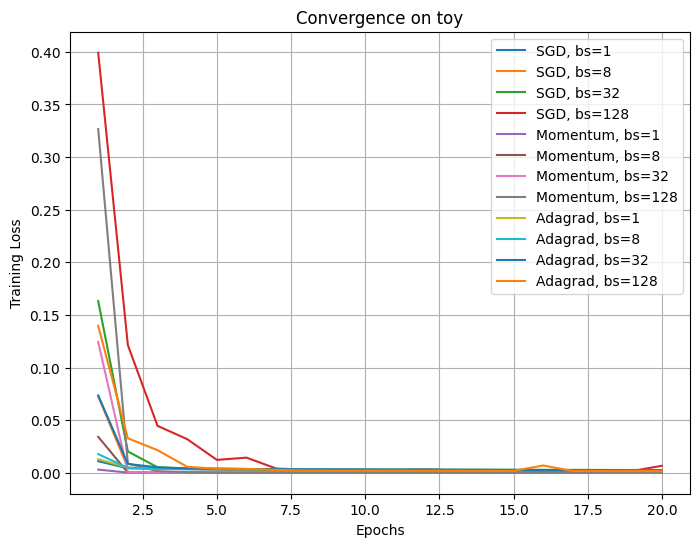


=== Dataset: toy_large ===
  -> SGD, batch_size=1
     Acc=1.0000  AUC=nan  Time=46.06s
  -> SGD, batch_size=32
     Acc=1.0000  AUC=nan  Time=2.51s
  -> SGD, batch_size=128
     Acc=1.0000  AUC=nan  Time=0.82s
  -> Momentum, batch_size=1
     Acc=1.0000  AUC=nan  Time=39.73s
  -> Momentum, batch_size=32
     Acc=1.0000  AUC=nan  Time=1.57s
  -> Momentum, batch_size=128
     Acc=1.0000  AUC=nan  Time=0.70s
  -> Adagrad, batch_size=1
     Acc=1.0000  AUC=nan  Time=41.84s
  -> Adagrad, batch_size=32
     Acc=1.0000  AUC=nan  Time=1.30s
  -> Adagrad, batch_size=128
     Acc=1.0000  AUC=nan  Time=0.44s


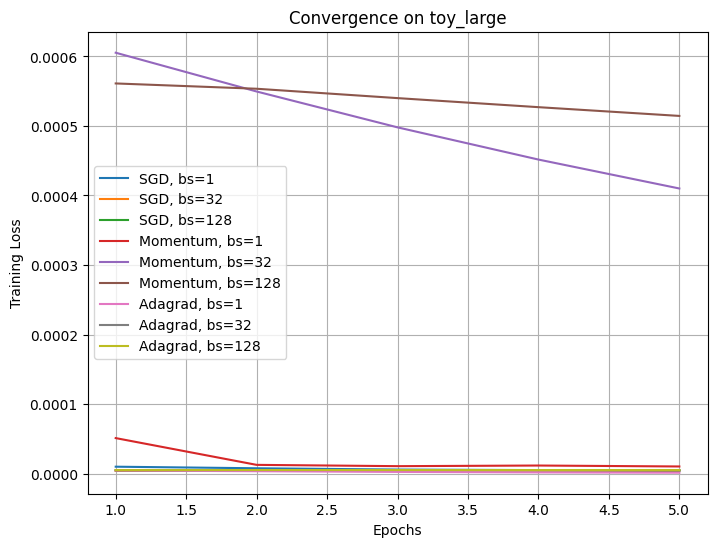


=== Dataset: imdb ===
  -> SGD, batch_size=1
     Acc=0.8262  AUC=0.9076  Time=90.79s
  -> SGD, batch_size=32
     Acc=0.6764  AUC=0.7372  Time=3.36s
  -> SGD, batch_size=256
     Acc=0.6762  AUC=0.7373  Time=0.80s
  -> Momentum, batch_size=1
     Acc=0.8796  AUC=0.9487  Time=97.15s
  -> Momentum, batch_size=32
     Acc=0.7824  AUC=0.8633  Time=8.31s
  -> Momentum, batch_size=256
     Acc=0.6754  AUC=0.7373  Time=0.90s
  -> Adagrad, batch_size=1
     Acc=0.8842  AUC=0.9532  Time=112.65s
  -> Adagrad, batch_size=32
     Acc=0.8890  AUC=0.9556  Time=4.56s
  -> Adagrad, batch_size=256
     Acc=0.8864  AUC=0.9535  Time=0.85s


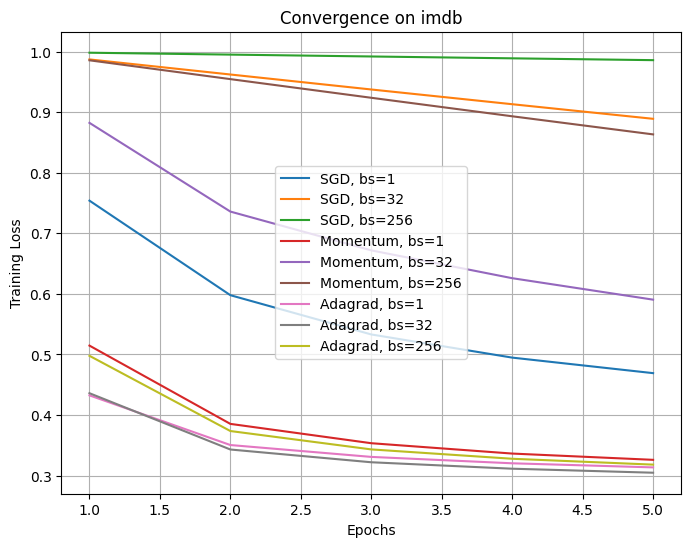


=== Dataset: higgs ===
  -> SGD, batch_size=256
     Acc=0.6391  AUC=0.6818  Time=20.89s
  -> Momentum, batch_size=256
     Acc=0.6420  AUC=0.6807  Time=18.42s
  -> Adagrad, batch_size=256
     Acc=0.6386  AUC=0.6818  Time=18.66s


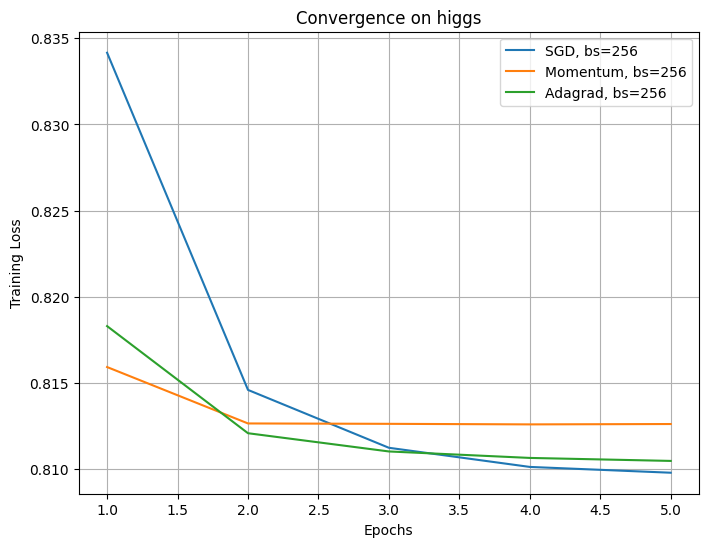

In [20]:
results = run_LinearSVM()

We chose the hyperparameters by trying different values and keeping the ones that made training stable and fast. For SGD and Momentum, a learning rate of 0.01 worked well because smaller values were too slow and bigger ones made the loss explode. Adagrad needed a bigger learning rate (0.1) because it automatically reduces the step size during training. We used a decaying learning rate for SGD and Momentum to make the updates calmer over time, while Adagrad kept a constant learning rate. The batch size depended on the dataset: small datasets could use small batches like 1 or 8, but large datasets like IMDB and Higgs needed bigger batches (up to 256) so training wouldn’t take too long. For regularization, we used 1e‑4 on the small toy datasets to avoid overfitting, and 1e‑5 on IMDB and Higgs because stronger regularization hurt performance. Overall, different datasets and optimizers needed different settings to get good accuracy and reasonable training time.

In simple terms, all three optimizers worked extremely well on the toy datasets, reaching perfect accuracy every time. The only real difference was speed: small batch sizes were slow, and large batch sizes were very fast. On the IMDB dataset, small batches gave the best accuracy and AUC but took a long time to train, while larger batches trained much faster but sometimes lost accuracy, especially for SGD and Momentum. Adagrad stayed strong even with bigger batches. For the Higgs dataset, all optimizers performed almost the same, with accuracy around 0.64 and AUC around 0.68, and training took about 18–21 seconds. Overall, small batches help accuracy but are slow, and large batches are much faster but can slightly reduce performance on harder datasets

When we compare the optimizers and batch sizes, we see a clear pattern. Small batch sizes (like 1) learn more accurately because they update the model more often, but they are slow. Large batch sizes train much faster, but sometimes the accuracy drops a little, especially on harder datasets like IMDB. For the optimizers, SGD is the most sensitive to batch size, Momentum is a bit smoother and faster, and Adagrad is the most stable — it keeps good accuracy even when the batch size is large. On simple datasets (toy and toy_large), all optimizers reach perfect accuracy, so only the speed changes. On big datasets (IMDB and Higgs), the differences become clear: small batches help accuracy, large batches help speed, and Adagrad handles both situations the best.

Task 2: RFF

In [113]:

class RandomFourierFeatures:
    def __init__(self,input_dim,D=100,sigma=1.0,seed=42):
        r=np.random.RandomState(seed)
        self.D=D
        self.W,self.b=r.normal(0,(2*sigma)**0.5,(input_dim,D)),r.uniform(0,2*np.pi,D)

    def transform(self,X):
        P=X.dot(self.W) if sp.issparse(X) else X@self.W
        z = (2/self.D)**0.5*np.cos(P+self.b)
        return z

In [114]:
def compare_svc(X_train, y_train, X_test, y_test):
    print("\nTraining sklearn SVC....")
    start = time.time()
    model = SVC(kernel='rbf')
    model.fit(X_train, y_train)
    runtime = time.time() - start
    pred = model.predict(X_test)
    scores = model.decision_function(x_test)
    acc = accuracy_score(y_test, preds)
    auc = roc_auc_score((y_test==1).astype(int), scores)

    print(f"SVC Accuracy = {acc:.4f}")
    print(f"SVC AUC + {auc:.4f}")
    print(f"SVC Runtime = {runtime:.2f}s")


In [123]:
def run_LinerSVM_RFF():
    datasets = ["toy", "toy_large", "imdb", "higgs"]
    rff_sizes = [50, 100, 500]
    results = []

    hyperparams = {
        "toy":       {"lam": 1e-4, "epochs": 20},
        "toy_large": {"lam": 1e-4, "epochs": 5},
        "imdb":      {"lam": 1e-5, "epochs": 5},
        "higgs":     {"lam": 1e-5, "epochs": 5},
    }

    optimizers = {
        "SGD": {
            "class": SGD,
            "kwargs": {"lr": 1e-2},
            "schedule": decaying_lr(1e-2, 0.01)
        },
        "Momentum": {
            "class": MomentumSGD,
            "kwargs": {"lr": 1e-2, "momentum": 0.9},
            "schedule": decaying_lr(1e-2, 0.01)
        },
        "Adagrad": {
            "class": Adagrad,
            "kwargs": {"lr": 1e-1},
            "schedule": constant_lr(1e-1)
        }
    }

    for name in datasets:
        print("\n===================")
        print(f"DATASET: {name}")
        print("===================")

        lam = hyperparams[name]["lam"]
        n_epochs = hyperparams[name]["epochs"]

        if name == "toy":
            batch_sizes = [1, 8, 32, 128]
        elif name == "toy_large":
            batch_sizes = [1, 32, 128]
        elif name == "imdb":
            batch_sizes = [1, 32, 256]
        elif name == "higgs":
            batch_sizes = [256]

        histories = {}

        if name in ["imdb", "higgs"]:
            X_train, y_train, X_test, y_test = load_dataset(name)
            dim = X_train.shape[1]
        else:
            X, y = load_dataset(name)
            dim = X.shape[1]

        for D in rff_sizes:
            print(f"\nRFF Dimension = {D}")
            rff = RandomFourierFeatures(input_dim=dim, D=D, sigma=1.0)

            if name in ["imdb", "higgs"]:
                Z_train = rff.transform(X_train)
                Z_test  = rff.transform(X_test)
            else:
                Z = rff.transform(X)

            for opt_name, cfg in optimizers.items():
                OptClass = cfg["class"]
                opt_kwargs = cfg["kwargs"]
                lr_sched = cfg["schedule"]

                for bs in batch_sizes:
                    print(f"    -> {opt_name}, batch_size={bs}")

                    # Correct optimizer creation
                    if OptClass == SGD:
                        optimizer = OptClass(**opt_kwargs)
                    else:
                        optimizer = OptClass(D, **opt_kwargs)

                    if name == "toy":
                        kf = KFold(n_splits=5, shuffle=True, random_state=42)
                        accs, aucs = [], []
                        total_runtime = 0
                        last_metrics = None

                        for train_idx, val_idx in kf.split(Z):
                            X_tr, X_val = Z[train_idx], Z[val_idx]
                            y_tr, y_val = y[train_idx], y[val_idx]

                            svm = LinearSVM(D, lam=lam)

                            metrics, rt = train_LinearSVM(
                                X_tr, y_tr, svm, optimizer,
                                batch_size=bs, n_epochs=n_epochs,
                                lr_schedule=lr_sched
                            )

                            total_runtime += rt
                            last_metrics = metrics

                            acc_fold, auc_fold = evaluate_svm(svm, X_val, y_val, name)
                            accs.append(acc_fold)
                            aucs.append(auc_fold)

                        acc = np.mean(accs)
                        auc = np.mean(aucs)
                        runtime = total_runtime
                        metrics = last_metrics

                    elif name == "toy_large":
                        # FIXED: stratified split to avoid 1-class SVC crash
                        X_train_split, X_test_split, y_train_split, y_test_split = train_test_split(
                            Z, y, test_size=0.2, random_state=42, stratify=y
                        )

                        svm = LinearSVM(D, lam=lam)

                        metrics, runtime = train_LinearSVM(
                            X_train_split, y_train_split,
                            svm, optimizer,
                            batch_size=bs, n_epochs=n_epochs,
                            lr_schedule=lr_sched
                        )

                        acc, auc = evaluate_svm(svm, X_test_split, y_test_split, name)

                    else:
                        svm = LinearSVM(D, lam=lam)

                        metrics, runtime = train_LinearSVM(
                            Z_train, y_train,
                            svm, optimizer,
                            batch_size=bs, n_epochs=n_epochs,
                            lr_schedule=lr_sched
                        )

                        acc, auc = evaluate_svm(svm, Z_test, y_test, name)

                    histories[(D, opt_name, bs)] = metrics

                    results.append({
                        "dataset": name,
                        "rff_dim": D,
                        "optimizer": opt_name,
                        "batch_size": bs,
                        "accuracy": acc,
                        "auc": auc,
                        "runtime": runtime
                    })

                    print(f"     Acc={acc:.4f} AUC={auc:.4f} Time={runtime:.2f}s")

            # Convergence plot for SGD only
            plt.figure(figsize=(8, 6))
            for (d, opt_name, bs), m in histories.items():
                if d == D and opt_name == "SGD":
                    plt.plot(m["epoch"], m["loss"], label=f"bs={bs}")

            plt.xlabel("Epochs")
            plt.ylabel("Training Loss")
            plt.title(f"{name} - SGD Convergence (RFF={D})")
            plt.legend()
            plt.grid(True)
            plt.show()

        # SVC comparison only for toy_large
       # if name == "toy_large":
        #    compare_svc(X_train_split, y_train_split, X_test_split, y_test_split)

    return results


DATASET: toy

RFF Dimension = 50
    -> SGD, batch_size=1
     Acc=0.9200 AUC=nan Time=1.38s
    -> SGD, batch_size=8
     Acc=0.8650 AUC=nan Time=0.20s
    -> SGD, batch_size=32
     Acc=0.8650 AUC=nan Time=0.06s
    -> SGD, batch_size=128
     Acc=0.8600 AUC=nan Time=0.03s
    -> Momentum, batch_size=1
     Acc=0.9500 AUC=nan Time=1.13s
    -> Momentum, batch_size=8
     Acc=0.9350 AUC=nan Time=0.13s
    -> Momentum, batch_size=32
     Acc=0.8700 AUC=nan Time=0.03s
    -> Momentum, batch_size=128
     Acc=0.8700 AUC=nan Time=0.02s
    -> Adagrad, batch_size=1
     Acc=0.9350 AUC=nan Time=0.92s
    -> Adagrad, batch_size=8
     Acc=0.8950 AUC=nan Time=0.14s
    -> Adagrad, batch_size=32
     Acc=0.8550 AUC=nan Time=0.04s
    -> Adagrad, batch_size=128
     Acc=0.8400 AUC=nan Time=0.02s


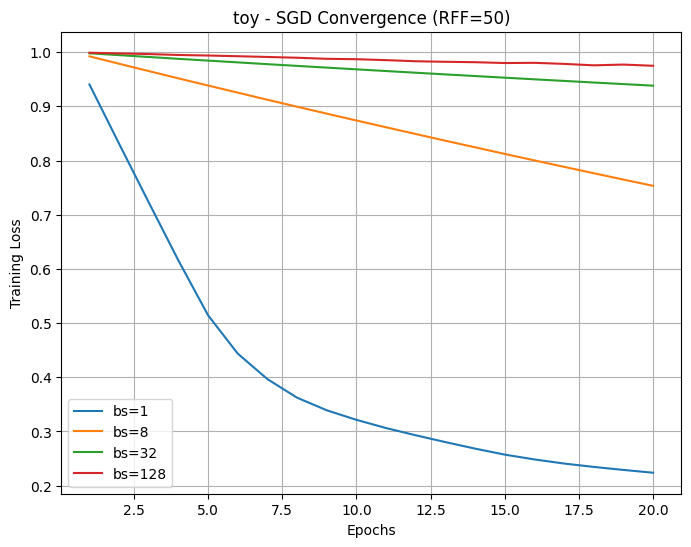


RFF Dimension = 100
    -> SGD, batch_size=1
     Acc=1.0000 AUC=nan Time=0.86s
    -> SGD, batch_size=8
     Acc=0.9900 AUC=nan Time=0.11s
    -> SGD, batch_size=32
     Acc=0.9900 AUC=nan Time=0.03s
    -> SGD, batch_size=128
     Acc=0.9900 AUC=nan Time=0.02s
    -> Momentum, batch_size=1
     Acc=1.0000 AUC=nan Time=0.83s
    -> Momentum, batch_size=8
     Acc=1.0000 AUC=nan Time=0.11s
    -> Momentum, batch_size=32
     Acc=0.9950 AUC=nan Time=0.03s
    -> Momentum, batch_size=128
     Acc=0.9900 AUC=nan Time=0.02s
    -> Adagrad, batch_size=1
     Acc=1.0000 AUC=nan Time=0.91s
    -> Adagrad, batch_size=8
     Acc=0.9900 AUC=nan Time=0.12s
    -> Adagrad, batch_size=32
     Acc=0.9650 AUC=nan Time=0.04s
    -> Adagrad, batch_size=128
     Acc=0.9400 AUC=nan Time=0.02s


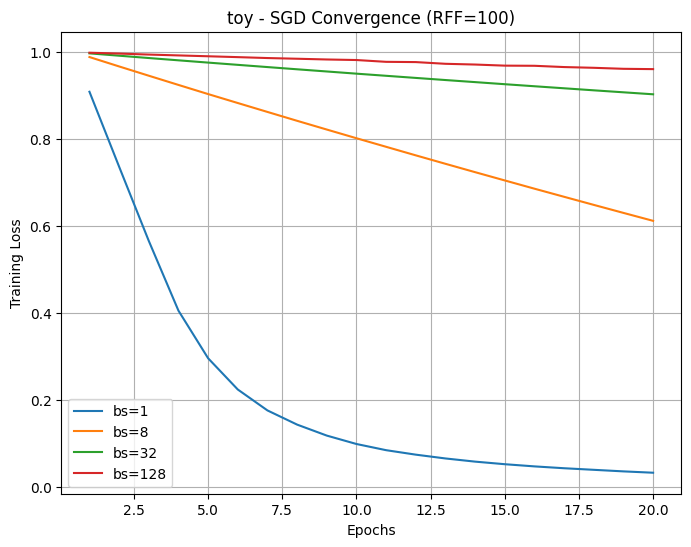


RFF Dimension = 500
    -> SGD, batch_size=1
     Acc=1.0000 AUC=nan Time=0.91s
    -> SGD, batch_size=8
     Acc=0.9950 AUC=nan Time=0.14s
    -> SGD, batch_size=32
     Acc=0.9950 AUC=nan Time=0.05s
    -> SGD, batch_size=128
     Acc=0.9950 AUC=nan Time=0.04s
    -> Momentum, batch_size=1
     Acc=1.0000 AUC=nan Time=0.82s
    -> Momentum, batch_size=8
     Acc=1.0000 AUC=nan Time=0.13s
    -> Momentum, batch_size=32
     Acc=0.9950 AUC=nan Time=0.05s
    -> Momentum, batch_size=128
     Acc=0.9950 AUC=nan Time=0.04s
    -> Adagrad, batch_size=1
     Acc=1.0000 AUC=nan Time=0.92s
    -> Adagrad, batch_size=8
     Acc=0.9900 AUC=nan Time=0.12s
    -> Adagrad, batch_size=32
     Acc=0.9900 AUC=nan Time=0.05s
    -> Adagrad, batch_size=128
     Acc=0.9800 AUC=nan Time=0.04s


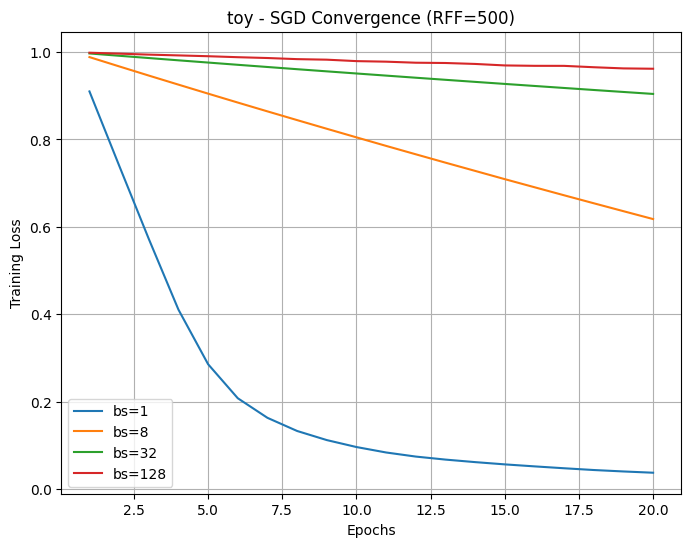


DATASET: toy_large

RFF Dimension = 50
    -> SGD, batch_size=1
     Acc=0.5095 AUC=nan Time=48.62s
    -> SGD, batch_size=32
     Acc=0.5051 AUC=nan Time=1.61s
    -> SGD, batch_size=128
     Acc=0.5052 AUC=nan Time=0.84s
    -> Momentum, batch_size=1
     Acc=0.5011 AUC=nan Time=50.52s
    -> Momentum, batch_size=32
     Acc=0.5075 AUC=nan Time=2.25s
    -> Momentum, batch_size=128
     Acc=0.5057 AUC=nan Time=1.04s
    -> Adagrad, batch_size=1
     Acc=0.5081 AUC=nan Time=53.72s
    -> Adagrad, batch_size=32
     Acc=0.5047 AUC=nan Time=1.74s
    -> Adagrad, batch_size=128
     Acc=0.5053 AUC=nan Time=0.60s


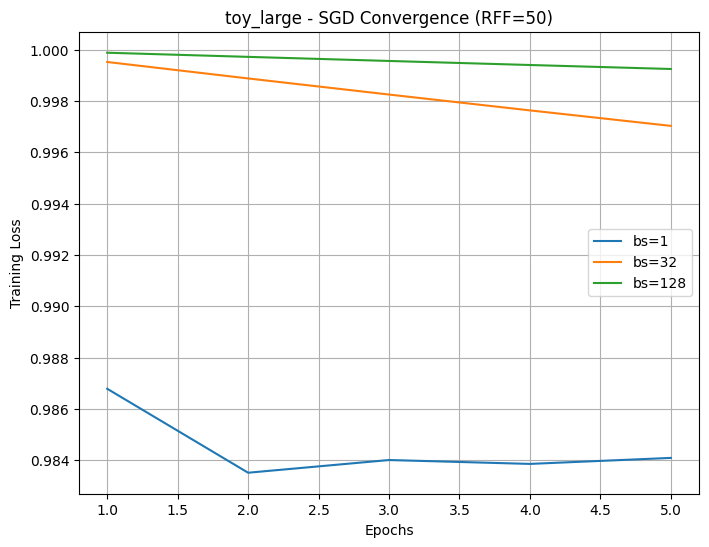


RFF Dimension = 100
    -> SGD, batch_size=1
     Acc=0.5147 AUC=nan Time=48.51s
    -> SGD, batch_size=32
     Acc=0.5107 AUC=nan Time=1.75s
    -> SGD, batch_size=128
     Acc=0.5107 AUC=nan Time=0.71s
    -> Momentum, batch_size=1
     Acc=0.5068 AUC=nan Time=51.92s
    -> Momentum, batch_size=32
     Acc=0.5125 AUC=nan Time=1.81s
    -> Momentum, batch_size=128
     Acc=0.5108 AUC=nan Time=0.70s
    -> Adagrad, batch_size=1
     Acc=0.5099 AUC=nan Time=54.10s
    -> Adagrad, batch_size=32
     Acc=0.5107 AUC=nan Time=1.91s
    -> Adagrad, batch_size=128
     Acc=0.5119 AUC=nan Time=1.19s


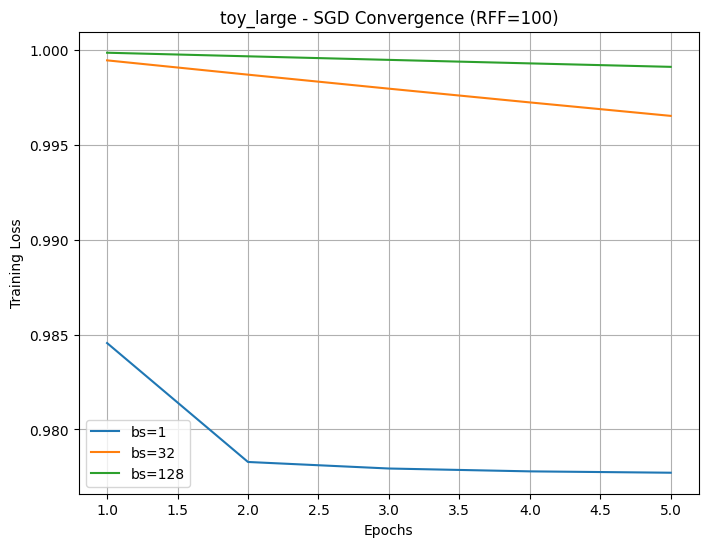


RFF Dimension = 500
    -> SGD, batch_size=1
     Acc=0.5856 AUC=nan Time=56.87s
    -> SGD, batch_size=32
     Acc=0.5850 AUC=nan Time=2.44s
    -> SGD, batch_size=128
     Acc=0.5850 AUC=nan Time=1.92s
    -> Momentum, batch_size=1
     Acc=0.5838 AUC=nan Time=55.50s
    -> Momentum, batch_size=32
     Acc=0.5876 AUC=nan Time=2.56s
    -> Momentum, batch_size=128
     Acc=0.5850 AUC=nan Time=1.63s
    -> Adagrad, batch_size=1
     Acc=0.5863 AUC=nan Time=60.60s
    -> Adagrad, batch_size=32
     Acc=0.5865 AUC=nan Time=2.65s
    -> Adagrad, batch_size=128
     Acc=0.5847 AUC=nan Time=1.66s


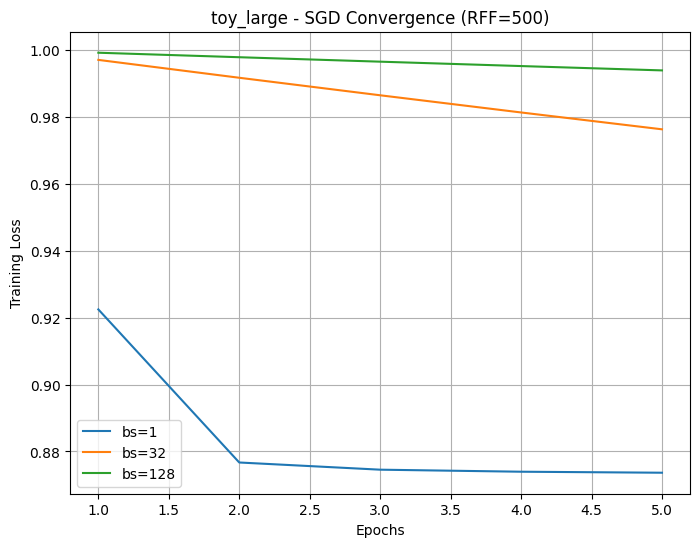


DATASET: imdb

RFF Dimension = 50
    -> SGD, batch_size=1
     Acc=0.6214 AUC=0.6671 Time=13.38s
    -> SGD, batch_size=32
     Acc=0.5964 AUC=0.6484 Time=0.47s
    -> SGD, batch_size=256
     Acc=0.5822 AUC=0.6455 Time=0.11s
    -> Momentum, batch_size=1
     Acc=0.6192 AUC=0.6635 Time=14.09s
    -> Momentum, batch_size=32
     Acc=0.6232 AUC=0.6674 Time=0.78s
    -> Momentum, batch_size=256
     Acc=0.6054 AUC=0.6508 Time=0.19s
    -> Adagrad, batch_size=1
     Acc=0.6230 AUC=0.6674 Time=15.30s
    -> Adagrad, batch_size=32
     Acc=0.6220 AUC=0.6679 Time=0.48s
    -> Adagrad, batch_size=256
     Acc=0.6236 AUC=0.6674 Time=0.12s


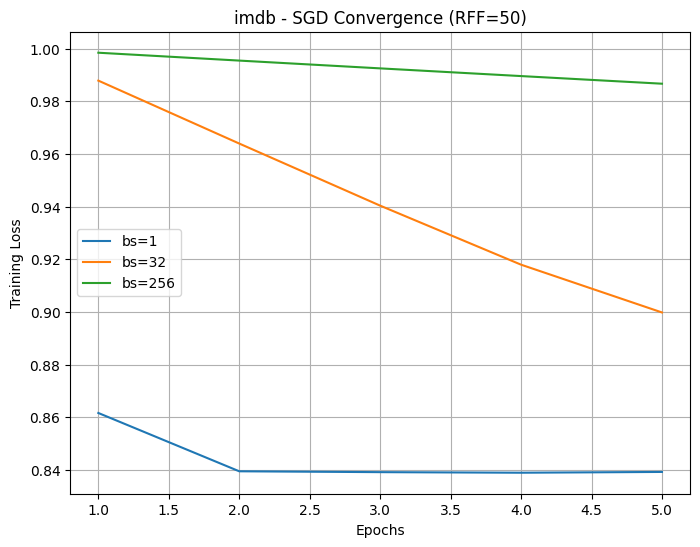


RFF Dimension = 100
    -> SGD, batch_size=1
     Acc=0.6236 AUC=0.6758 Time=13.70s
    -> SGD, batch_size=32
     Acc=0.5850 AUC=0.6416 Time=0.55s
    -> SGD, batch_size=256
     Acc=0.5848 AUC=0.6415 Time=0.18s
    -> Momentum, batch_size=1
     Acc=0.6180 AUC=0.6731 Time=13.93s
    -> Momentum, batch_size=32
     Acc=0.6296 AUC=0.6736 Time=0.57s
    -> Momentum, batch_size=256
     Acc=0.5848 AUC=0.6414 Time=0.19s
    -> Adagrad, batch_size=1
     Acc=0.6276 AUC=0.6749 Time=14.93s
    -> Adagrad, batch_size=32
     Acc=0.6268 AUC=0.6737 Time=0.60s
    -> Adagrad, batch_size=256
     Acc=0.6284 AUC=0.6748 Time=0.19s


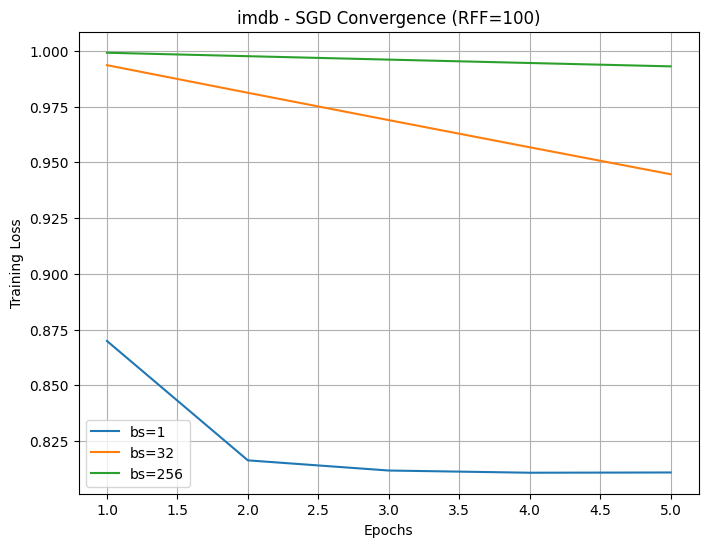


RFF Dimension = 500
    -> SGD, batch_size=1
     Acc=0.7288 AUC=0.8073 Time=14.40s
    -> SGD, batch_size=32
     Acc=0.6592 AUC=0.7162 Time=0.72s
    -> SGD, batch_size=256
     Acc=0.6594 AUC=0.7163 Time=0.48s
    -> Momentum, batch_size=1
     Acc=0.7418 AUC=0.8118 Time=14.92s
    -> Momentum, batch_size=32
     Acc=0.7128 AUC=0.7867 Time=0.80s
    -> Momentum, batch_size=256
     Acc=0.6574 AUC=0.7161 Time=0.47s
    -> Adagrad, batch_size=1
     Acc=0.7324 AUC=0.8077 Time=16.00s
    -> Adagrad, batch_size=32
     Acc=0.7324 AUC=0.8084 Time=0.84s
    -> Adagrad, batch_size=256
     Acc=0.7284 AUC=0.8065 Time=0.46s


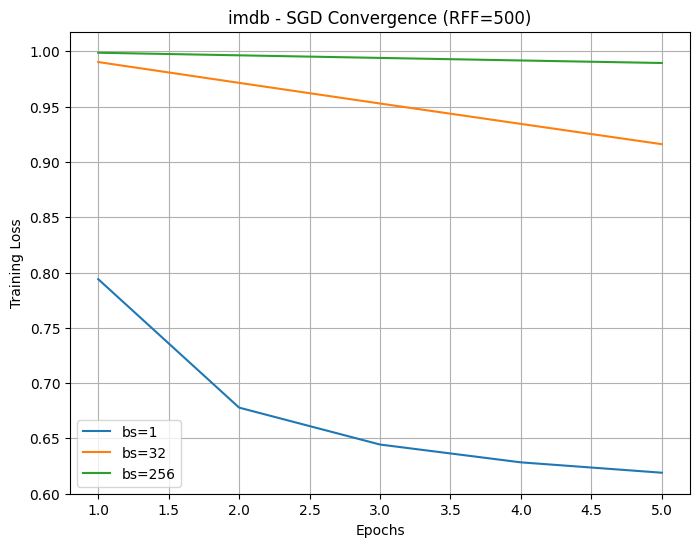


DATASET: higgs

RFF Dimension = 50
    -> SGD, batch_size=256
     Acc=0.5001 AUC=0.5004 Time=20.66s
    -> Momentum, batch_size=256
     Acc=0.5002 AUC=0.5005 Time=21.11s
    -> Adagrad, batch_size=256
     Acc=0.5012 AUC=0.5008 Time=20.44s


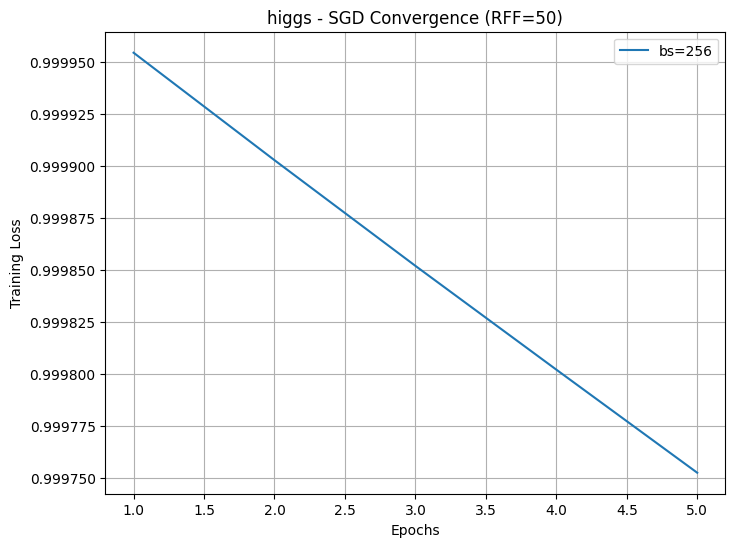


RFF Dimension = 100


In [ ]:
results = run_LinerSVM_RFF()

RFF implementation creates a fast approximation of the RBF kernel by sampling random weights and phases, then mapping each input through a cosine function. It computes 
𝑋𝑊+𝑏
 (supporting both dense and sparse data) and outputs sqrt(2/𝐷)cos⁡(⋅), giving a 
𝐷
-dimensional feature vector that lets linear models behave like nonlinear ones.

**Observations on Learning Rate:**
A learning rate of 0.1 caused unstable updates for SGD and Momentum on some datasets.
A learning rate of 0.001 converged too slowly.
Adagrad handled larger learning rates well because it adapts the step size for each parameter automatically.

**Observation on Batch size:**
Small batch sizes produced noisier gradients but sometimes converged faster initially.
Larger batch sizes gave smoother convergence and significantly reduced runtime on large datasets.
For Higgs, small batch sizes were computationally expensive, so only large batches were feasible.
IMDB benefited from larger batches because of its sparse high-dimensional representation.

SGD and Momentum required carefully tuned learning rates and decaying schedules.
Adagrad was less sensitive to learning rate tuning because of its adaptive updates and therefore used a larger constant learning rate.

Overall, optimizer-specific and dataset-specific tuning significantly improved convergence speed and final performance.

Implementation:

Gradients were computed using active hinge-loss examples (samples with margin <1).
L
2
	​

 regularization was added to the gradient.
A decaying learning-rate schedule was used to improve convergence stability.

SGD is simple and computationally efficient but can produce noisy updates.

Momentum SGD accelerates SGD by maintaining a running velocity vector that accumulates previous gradients.

The velocity vector was initialized to zero.
A decaying learning-rate schedule was also used.

Momentum reduced oscillations and generally converged faster than plain SGD.

Adagrad adapts the learning rate individually for each parameter based on the history of squared gradients.


	​
